<a href="https://colab.research.google.com/github/berevai/METODOS-NUMERICOS/blob/main/M%C3%A9todo_del_punto_fijo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Método del Punto Fijo**

Para resolver ecuaciones no lineales hay varios métodos muy útiles:



*   Métodos Cerrados (o de intervalo)
*   Métodos Abiertos
*   Métodos Especiales para polinomios.

   


En este ejercicio utilizaremos un método diferente al de bisección: **El Método Abierto de Iteración de Punto Fijo**. A diferencia de los métodos cerrados, este no requiere que la función cambie de signo en los extremos, pero a cambio, necesitamos una buena aproximación inicial y una función bien comportada

Para que el método funcione, nuestra función $g(x)$ debe "mapear" el intervalo dentro de sí mismo (es decir, si le metemos un número entre $a$ y $b$, el resultado también debe estar entre $a$ y $b$).

Pero el secreto de la convergencia está en la derivada: si $|g'(x)|$ es menor que 1, significa que la función es "contractiva". Cada vez que iteramos, los valores se van acercando más y más a la raíz, como si la función los atrajera hacia el punto fijo. Si la derivada fuera mayor que 1, el método divergiría y los valores se alejarían.

Por eso es crucial elegir bien nuestra $g(x)$. En el código, veremos cómo esta elección afecta directamente el resultado.

Queremos resolver la ecuación:

$x^3 + 4x^2 - 10 = 0$

en el intervalo $[1, 2]$.

El libro nos sugiere manipular algebraicamente la ecuación para obtener una función de punto fijo $g(x)$. Despejando $x^2$:

$4x^2 = 10 - x^3 \implies x^2 = \frac{1}{4}(10 - x^3) \implies x = \pm \frac{1}{2}\sqrt{10 - x^3}$

Como estamos buscando una solución positiva en $[1, 2]$, seleccionamos la raíz positiva. Por lo tanto, nuestra función de iteración es:

$g_3(x) = \frac{1}{2}\sqrt{10 - x^3}$

In [1]:
# Importamos las librerías necesarias
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# Definimos la función de punto fijo g(x)
def g(x):
    return 0.5 * np.sqrt(10 - x**3)

In [3]:
def punto_fijo(p0, tolerancia, max_iter):
    # Inicializamos contador
    i = 1
    historial = [] # Para guardar los datos de cada paso

    print(f"{'Iter':<6} {'p_{i-1}':<12} {'p_i':<12} {'Error':<12}")
    print("-" * 45)

    # Mientras i <= N0
    while i <= max_iter:
        # Calculamos p = g(p0)
        p = g(p0)

        # Calculamos el error
        error = abs(p - p0)

        # Guardamos en historial
        historial.append([i, p0, p, error])

        # Imprimimo fila de la tabla
        print(f"{i:<6} {p0:<12.8f} {p:<12.8f} {error:<12.8f}")

        # Si |p - p0| < TOL, salida exitosa
        if error < tolerancia:
            print("-" * 45)
            print(f"Procedimiento exitoso! La raíz aproximada es p = {p:.9f}")
            return p, historial

        # i = i + 1
        i += 1

        # p0 = p (Actualizar)
        p0 = p

    # Por si falla
    print(f"El método falló después de {max_iter} iteraciones.")
    return None, historial

In [4]:
# Definimos los parámetros de entrada
p0_inicial = 1.5
TOL = 1e-4  # Esto es 10 a la menos 4
N0 = 100

# Llamamos a la función
raiz, historial = punto_fijo(p0_inicial, TOL, N0)

Iter   p_{i-1}      p_i          Error       
---------------------------------------------
1      1.50000000   1.28695377   0.21304623  
2      1.28695377   1.40254080   0.11558704  
3      1.40254080   1.34545837   0.05708243  
4      1.34545837   1.37517025   0.02971188  
5      1.37517025   1.36009419   0.01507606  
6      1.36009419   1.36784697   0.00775277  
7      1.36784697   1.36388700   0.00395996  
8      1.36388700   1.36591673   0.00202973  
9      1.36591673   1.36487822   0.00103852  
10     1.36487822   1.36541006   0.00053184  
11     1.36541006   1.36513782   0.00027224  
12     1.36513782   1.36527721   0.00013939  
13     1.36527721   1.36520585   0.00007136  
---------------------------------------------
Procedimiento exitoso! La raíz aproximada es p = 1.365205850


Para entenderlo mejor, podemos graficar dos cosas:

1. La recta $y = x$ (la identidad).
2. La curva $y = g(x)$.

El punto donde se cruzan es exactamente nuestra raíz (el punto fijo). Vamos a graficar la función de iteración g(x):


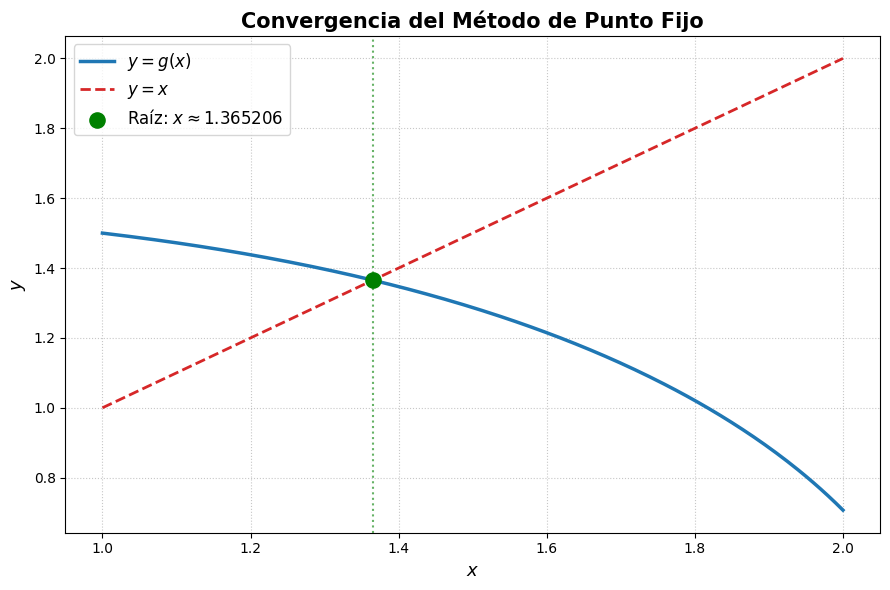

In [15]:
# Generamos una retícula de puntos para graficar
x_vals = np.linspace(1, 2, 200)

# Creamos la figura
plt.figure(figsize=(9, 6))

# Graficamos y = g(x)
plt.plot(x_vals, g(x_vals), label="$y = g(x)$", color="#1f77b4", linewidth=2.5)

# Graficamos y = x
plt.plot(x_vals, x_vals, label="$y = x$", color="#d62728", linestyle="--", linewidth=2)

# Marcamos la raíz exacta encontrada
plt.scatter(raiz, raiz, color="green", s=120, zorder=5,
            label=f"Raíz: $x \\approx {raiz:.6f}$")

# Agregamos una línea punteada vertical en la raíz para mayor claridad
plt.axvline(x=raiz, color="green", linestyle=":", alpha=0.6)

# Personalización
plt.title("Convergencia del Método de Punto Fijo", fontsize=15, fontweight="bold")
plt.xlabel("$x$", fontsize=13)
plt.ylabel("$y$", fontsize=13)
plt.grid(True, linestyle=":", alpha=0.7)
plt.legend(fontsize=12, loc="upper left")

plt.tight_layout()
plt.show()

¡Y listo! Como podemos observar en la gráfica y en la tabla de iteraciones, el método convergió rápidamente.

La solución final, con una precisión de $10^{-4}$, es:

$p \approx 1.36523001$


La clave está en la elección de $g(x)$. Para que el método de punto fijo converja, se necesita que $|g'(x)| < 1$ en el intervalo de interés. En este caso, la derivada de $g_3(x)$ es pequeña en $[1, 2]$, lo que garantiza que las iteraciones se vayan "pegando" poco a poco a la raíz. Si hubiéramos elegido otra $g(x)$, como $g_1(x)$, el método probablemente habría divergido.

*Rubio Ortega Berenice c:*